In [ ]:
!pip install mlflow

In [1]:
import os

base_path = "/kaggle/input/datasets/naveedqasim/dataset1/enrollments"

students = os.listdir(base_path)

print("TOTAL STUDENTS:", len(students))
print("\nSTUDENTS LIST:\n")

for s in students:
    print("-", s)

TOTAL STUDENTS: 16

STUDENTS LIST:

- Abdullah_Tariq
- Imran_Ghafoor
- M.Bilal_razzaq
- M.Mustafa_Umar
- Ali_Raza
- Mahad_khan
- Muhammad_Fahad
- Areez_khan
- Muhammad_Naveed
- Awais_ahmad
- Muhammad_Maaz
- AHMAD_BILAL
- SALMAN_Yaqoob
- Arooj_Naaz
- Ayesha_Azhar
- Muaaz_Tariq


In [2]:
for student in students:
    path = os.path.join(base_path, student)
    images = os.listdir(path)

    print("\nStudent:", student)
    print("Images:", len(images))
    print("Sample:", images[:3])


Student: Abdullah_Tariq
Images: 5
Sample: ['capture_5_2026-06-18_09-29-30.jpg', 'capture_1_2026-06-18_09-29-30.jpg', 'capture_2_2026-06-18_09-29-30.jpg']

Student: Imran_Ghafoor
Images: 5
Sample: ['capture_2_2026-06-18_09-47-48.jpg', 'capture_1_2026-06-18_09-47-48.jpg', 'capture_4_2026-06-18_09-47-48.jpg']

Student: M.Bilal_razzaq
Images: 5
Sample: ['capture_4_2026-06-18_13-30-13.jpg', 'capture_2_2026-06-18_13-30-13.jpg', 'capture_1_2026-06-18_13-30-13.jpg']

Student: M.Mustafa_Umar
Images: 5
Sample: ['capture_1_2026-06-18_09-28-24.jpg', 'capture_5_2026-06-18_09-28-24.jpg', 'capture_2_2026-06-18_09-28-24.jpg']

Student: Ali_Raza
Images: 5
Sample: ['capture_3_2026-06-18_09-44-05.jpg', 'capture_4_2026-06-18_09-44-05.jpg', 'capture_2_2026-06-18_09-44-05.jpg']

Student: Mahad_khan
Images: 5
Sample: ['capture_4_2026-06-18_09-25-47.jpg', 'capture_3_2026-06-18_09-25-47.jpg', 'capture_1_2026-06-18_09-25-47.jpg']

Student: Muhammad_Fahad
Images: 5
Sample: ['capture_5_2026-06-18_09-27-03.jpg', 

Showing: Mahad_khan


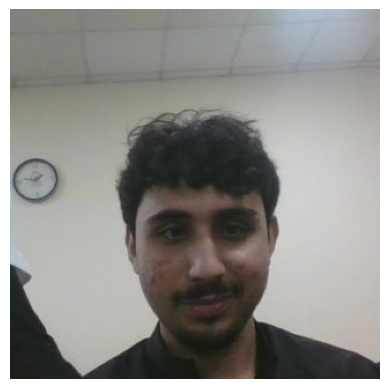

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

student = random.choice(students)
img_name = random.choice(os.listdir(os.path.join(base_path, student)))

img_path = os.path.join(base_path, student, img_name)

img = Image.open(img_path)

print("Showing:", student)
plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
from torchvision import transforms
from torchvision.datasets import ImageFolder

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

dataset = ImageFolder(root=base_path, transform=transform)

print("CLASSES (Students):")
print(dataset.classes)

print("\nCLASS MAP:")
print(dataset.class_to_idx)

print("\nTOTAL IMAGES:", len(dataset))

CLASSES (Students):
['AHMAD_BILAL', 'Abdullah_Tariq', 'Ali_Raza', 'Areez_khan', 'Arooj_Naaz', 'Awais_ahmad', 'Ayesha_Azhar', 'Imran_Ghafoor', 'M.Bilal_razzaq', 'M.Mustafa_Umar', 'Mahad_khan', 'Muaaz_Tariq', 'Muhammad_Fahad', 'Muhammad_Maaz', 'Muhammad_Naveed', 'SALMAN_Yaqoob']

CLASS MAP:
{'AHMAD_BILAL': 0, 'Abdullah_Tariq': 1, 'Ali_Raza': 2, 'Areez_khan': 3, 'Arooj_Naaz': 4, 'Awais_ahmad': 5, 'Ayesha_Azhar': 6, 'Imran_Ghafoor': 7, 'M.Bilal_razzaq': 8, 'M.Mustafa_Umar': 9, 'Mahad_khan': 10, 'Muaaz_Tariq': 11, 'Muhammad_Fahad': 12, 'Muhammad_Maaz': 13, 'Muhammad_Naveed': 14, 'SALMAN_Yaqoob': 15}

TOTAL IMAGES: 80


In [5]:
img, label = dataset[0]

print("Tensor Shape:", img.shape)
print("Label Index:", label)
print("Student Name:", dataset.classes[label])

Tensor Shape: torch.Size([3, 224, 224])
Label Index: 0
Student Name: AHMAD_BILAL


In [6]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from torchvision.models import resnet34, ResNet34_Weights

In [7]:
from torchvision import transforms

aug_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor()
])

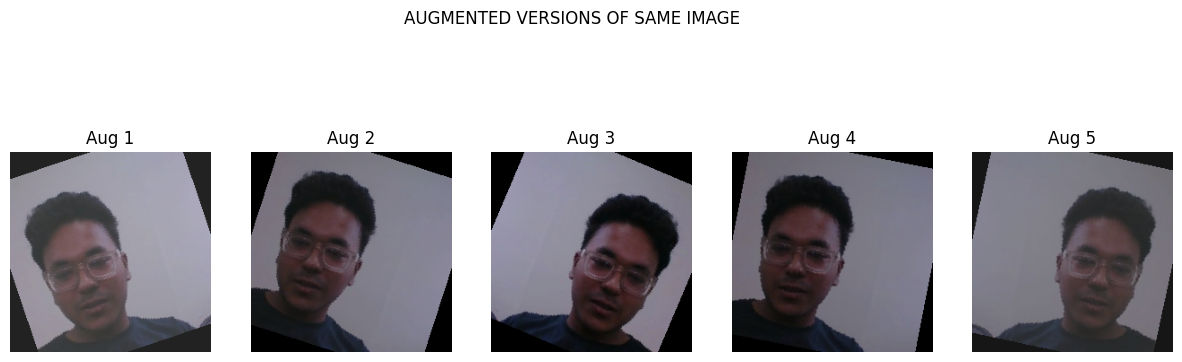

In [8]:
import torch

sample_class = random.choice(students)
sample_img = random.choice(os.listdir(os.path.join(base_path, sample_class)))

img_path = os.path.join(base_path, sample_class, sample_img)
img = Image.open(img_path)

fig, axes = plt.subplots(1, 5, figsize=(15,5))

for i in range(5):
    aug_img = aug_transform(img)
    aug_img = aug_img.permute(1,2,0).numpy()
    axes[i].imshow(aug_img)
    axes[i].axis("off")
    axes[i].set_title(f"Aug {i+1}")

plt.suptitle("AUGMENTED VERSIONS OF SAME IMAGE")
plt.show()

In [9]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(root=base_path, transform=aug_transform)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['AHMAD_BILAL', 'Abdullah_Tariq', 'Ali_Raza', 'Areez_khan', 'Arooj_Naaz', 'Awais_ahmad', 'Ayesha_Azhar', 'Imran_Ghafoor', 'M.Bilal_razzaq', 'M.Mustafa_Umar', 'Mahad_khan', 'Muaaz_Tariq', 'Muhammad_Fahad', 'Muhammad_Maaz', 'Muhammad_Naveed', 'SALMAN_Yaqoob']
Total Images: 80


In [10]:
print("DATASET SIZE (unchanged):", len(dataset))

print("\nEach epoch images will look different due to augmentation")

DATASET SIZE (unchanged): 80

Each epoch images will look different due to augmentation


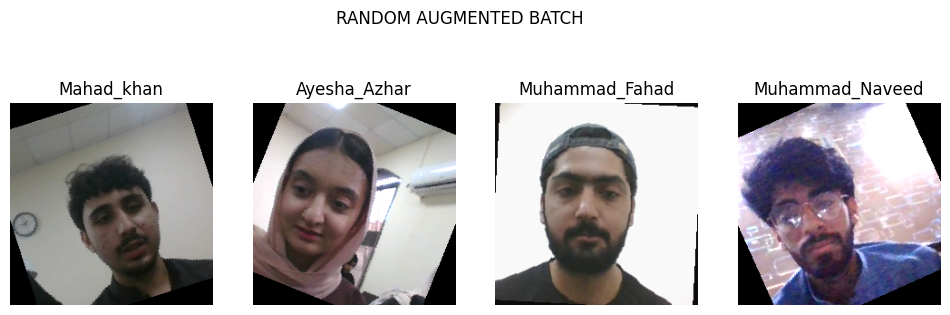

In [11]:
from torch.utils.data import DataLoader

loader = DataLoader(dataset, batch_size=4, shuffle=True)

images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 4, figsize=(12,4))

for i in range(4):
    img = images[i].permute(1,2,0).numpy()
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(dataset.classes[labels[i]])

plt.suptitle("RANDOM AUGMENTED BATCH")
plt.show()

In [12]:
import os
from torchvision.datasets import ImageFolder
from torchvision import transforms

base_path = "/kaggle/input/datasets/naveedqasim/dataset1/enrollments"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

dataset = ImageFolder(root=base_path, transform=transform)

print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['AHMAD_BILAL', 'Abdullah_Tariq', 'Ali_Raza', 'Areez_khan', 'Arooj_Naaz', 'Awais_ahmad', 'Ayesha_Azhar', 'Imran_Ghafoor', 'M.Bilal_razzaq', 'M.Mustafa_Umar', 'Mahad_khan', 'Muaaz_Tariq', 'Muhammad_Fahad', 'Muhammad_Maaz', 'Muhammad_Naveed', 'SALMAN_Yaqoob']
Total Images: 80


In [13]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))

Train images: 64
Test images: 16


In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

print("Dataloaders ready")

Dataloaders ready


In [15]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.pth'):
            print(os.path.join(root, f))

/kaggle/input/datasets/organizations/pytorch/resnet34/resnet34.pth


In [18]:
import os, shutil

os.makedirs('/root/.cache/torch/hub/checkpoints', exist_ok=True)

src = '/kaggle/input/datasets/organizations/pytorch/resnet34/resnet34.pth'
dst = '/root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth'

shutil.copy(src, dst)
print("Copied:", os.listdir('/root/.cache/torch/hub/checkpoints'))

Copied: ['resnet34-b627a593.pth']


In [19]:
from torchvision.models import resnet34, ResNet34_Weights
model = resnet34(weights=ResNet34_Weights.DEFAULT)
print("Loaded successfully, no internet needed.")

Loaded successfully, no internet needed.


In [20]:
for param in model.parameters():
    param.requires_grad = False

In [21]:
num_classes = len(dataset.classes)

model.fc = nn.Linear(model.fc.in_features, num_classes)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cuda


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

In [24]:
epochs = 10

import mlflow
import mlflow.pytorch

# Set MLflow experiment
mlflow.set_experiment("Face_Recognition_ResNet34")

# Start MLflow run
mlflow.start_run(run_name="Training_Run")

# Log parameters
mlflow.log_param("epochs", epochs)
mlflow.log_param("learning_rate", 0.001)
mlflow.log_param("batch_size", 8)
mlflow.log_param("optimizer", "Adam")
mlflow.log_param("loss_function", "CrossEntropyLoss")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    print(f"\n🔥 Epoch {epoch+1}/{epochs}")

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    print(f"Training Loss: {avg_train_loss:.4f}")
    
    # Log metric for each epoch
    mlflow.log_metric("train_loss", avg_train_loss, step=epoch)



🔥 Epoch 1/10
Batch 0 | Loss: 2.7131
Batch 2 | Loss: 2.7746
Batch 4 | Loss: 3.1186
Batch 6 | Loss: 3.7948
Epoch Loss: 26.522363424301147

🔥 Epoch 2/10
Batch 0 | Loss: 2.2703
Batch 2 | Loss: 2.9601
Batch 4 | Loss: 2.9487
Batch 6 | Loss: 2.6714
Epoch Loss: 21.738149166107178

🔥 Epoch 3/10
Batch 0 | Loss: 2.2177
Batch 2 | Loss: 2.4356
Batch 4 | Loss: 2.2413
Batch 6 | Loss: 2.5270
Epoch Loss: 19.464561462402344

🔥 Epoch 4/10
Batch 0 | Loss: 2.4306
Batch 2 | Loss: 2.1116
Batch 4 | Loss: 2.1641
Batch 6 | Loss: 2.0119
Epoch Loss: 17.352912187576294

🔥 Epoch 5/10
Batch 0 | Loss: 2.2599
Batch 2 | Loss: 1.6738
Batch 4 | Loss: 1.8269
Batch 6 | Loss: 1.9728
Epoch Loss: 15.936975836753845

🔥 Epoch 6/10
Batch 0 | Loss: 1.4293
Batch 2 | Loss: 1.9587
Batch 4 | Loss: 1.8327
Batch 6 | Loss: 2.1199
Epoch Loss: 14.054937839508057

🔥 Epoch 7/10
Batch 0 | Loss: 1.6478
Batch 2 | Loss: 1.8637
Batch 4 | Loss: 1.8519
Batch 6 | Loss: 1.5968
Epoch Loss: 12.958251595497131

🔥 Epoch 8/10
Batch 0 | Loss: 1.1318
Batc

In [25]:
model.eval()

correct = 0
total = 0
total_test_loss = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        total_test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
avg_test_loss = total_test_loss / len(test_loader)

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Test Loss: {avg_test_loss:.4f}")

# Log evaluation metrics
mlflow.log_metric("test_accuracy", accuracy)
mlflow.log_metric("test_loss", avg_test_loss)



🎯 FINAL ACCURACY: 87.5


In [26]:
torch.save(model.state_dict(), "face_recognition_resnet34.pth")

print("Model saved successfully!")

# Log the saved model to MLflow
mlflow.pytorch.log_model(model, "model")
mlflow.log_artifact("face_recognition_resnet34.pth")

# End MLflow run
mlflow.end_run()


Model saved successfully!


In [27]:
# ── Export class index -> student name mapping ──────────────
# Needed so the Flask app can turn a predicted class index back into a name.
import json

idx_to_class = {str(idx): name for name, idx in dataset.class_to_idx.items()}

with open("class_names.json", "w") as f:
    json.dump(idx_to_class, f, indent=2)

print("Saved class_names.json")
print(idx_to_class)

# Download both face_recognition_resnet34.pth and class_names.json
# from the Kaggle output panel (top-right "Output" / file browser),
# then place them in lockin/models/ on your laptop.

Saved class_names.json
{'0': 'AHMAD_BILAL', '1': 'Abdullah_Tariq', '2': 'Ali_Raza', '3': 'Areez_khan', '4': 'Arooj_Naaz', '5': 'Awais_ahmad', '6': 'Ayesha_Azhar', '7': 'Imran_Ghafoor', '8': 'M.Bilal_razzaq', '9': 'M.Mustafa_Umar', '10': 'Mahad_khan', '11': 'Muaaz_Tariq', '12': 'Muhammad_Fahad', '13': 'Muhammad_Maaz', '14': 'Muhammad_Naveed', '15': 'SALMAN_Yaqoob'}


In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pytorch/resnet34")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/pytorch/resnet34


In [29]:
from IPython.display import FileLink
FileLink('/kaggle/input/datasets/organizations/pytorch/resnet34/resnet34.pth')

/kaggle/input/datasets/organizations/pytorch/resnet34/resnet34.pth

In [30]:
!ls -lh /kaggle/working/face_recognition_resnet34.pth

-rw-r--r-- 1 root root 82M Jun 20 20:25 /kaggle/working/face_recognition_resnet34.pth


In [31]:
from IPython.display import FileLink
FileLink("/kaggle/working/face_recognition_resnet34.pth")

/kaggle/working/face_recognition_resnet34.pth

In [32]:
import zipfile

with zipfile.ZipFile("/kaggle/working/model.zip", "w") as z:
    z.write("/kaggle/working/face_recognition_resnet34.pth",
            "face_recognition_resnet34.pth")

print("ZIP created")

ZIP created


In [2]:
!pip install mlflow

^C
